In [3]:
!pip install fair-esm matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.2 MB/s eta 0:00:00


In [4]:
import torch
import esm

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model.eval()

batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [5]:
def get_embedding(seq):
    data = [("protein", seq)]
    _, _, tokens = batch_converter(data)

    with torch.no_grad():
        out = esm_model(tokens, repr_layers=[6])

    return out["representations"][6][0]

In [6]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("hazemessam/fireprot_db")
df = dataset['train'].to_pandas()

df = df[['sequence', 'position', 'wild_type', 'mutation', 'ddG']].dropna()

df['pos'] = df['position'] - 1
df = df[df.apply(lambda r: r['sequence'][r['pos']] == r['wild_type'], axis=1)]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

fireprotdb_results.csv:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53445 [00:00<?, ? examples/s]

In [7]:
df_small = df.sample(200, random_state=42).reset_index(drop=True)

In [8]:
import numpy as np
from tqdm import tqdm
import torch

X = []
y = []

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

for _, row in tqdm(df_small.iterrows(), total=len(df_small)):
    seq = row['sequence']
    pos = int(row['pos'])
    mut = row['mutation']
    ddg = row['ddG']

    wt_embed = get_embedding(seq)

    wt_vec = wt_embed[pos + 1]

    # FAST mutation simulation
    aa_index = amino_acids.index(mut)
    mut_vec = wt_vec.clone()
    mut_vec[aa_index % wt_vec.shape[0]] += 0.1

    feature = torch.cat([
        wt_vec,
        mut_vec,
        wt_vec - mut_vec,
        torch.abs(wt_vec - mut_vec)
    ])

    X.append(feature.numpy())
    y.append(ddg)

X = np.array(X)
y = np.array(y)

100%|██████████| 200/200 [00:36<00:00,  5.51it/s]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)

model_nn = MLP(X.shape[1])

optimizer = torch.optim.Adam(
    model_nn.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

for epoch in range(300):
    model_nn.train()

    preds = model_nn(X_train_t)
    loss = loss_fn(preds, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(epoch, loss.item())

0 3.687854766845703
50 0.10457728058099747
100 0.06476855278015137
150 0.04907160997390747
200 0.039425767958164215
250 0.03503769636154175


In [13]:
from scipy.stats import pearsonr

model_nn.eval()
with torch.no_grad():
    preds = model_nn(X_test_t).numpy().flatten()

corr, _ = pearsonr(y_test, preds)
print("Test Pearson:", corr)

Test Pearson: 0.6277423407620644


In [14]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 1.0848469484131682


In [15]:
import numpy as np
from tqdm import tqdm
import torch

sequence = "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKT"
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
L = len(sequence)

heatmap = np.zeros((20, L))

wt_embed = get_embedding(sequence)

model_nn.eval()

for i, aa in enumerate(amino_acids):
    for pos in tqdm(range(L)):
        if sequence[pos] == aa:
            continue
        mut_seq = list(sequence)
        mut_seq[pos] = aa
        mut_seq = "".join(mut_seq)

        mut_embed = get_embedding(mut_seq)

        wt_vec = wt_embed[pos + 1]
        mut_vec = mut_embed[pos + 1]

        feature = torch.cat([
            wt_vec,
            mut_vec,
            wt_vec - mut_vec,
            torch.abs(wt_vec - mut_vec)
        ]).numpy().reshape(1, -1)

        feature_scaled = scaler.transform(feature)

        with torch.no_grad():
            pred = model_nn(torch.tensor(feature_scaled, dtype=torch.float32))

        heatmap[i, pos] = pred.item()

100%|██████████| 54/54 [00:01<00:00, 44.75it/s]


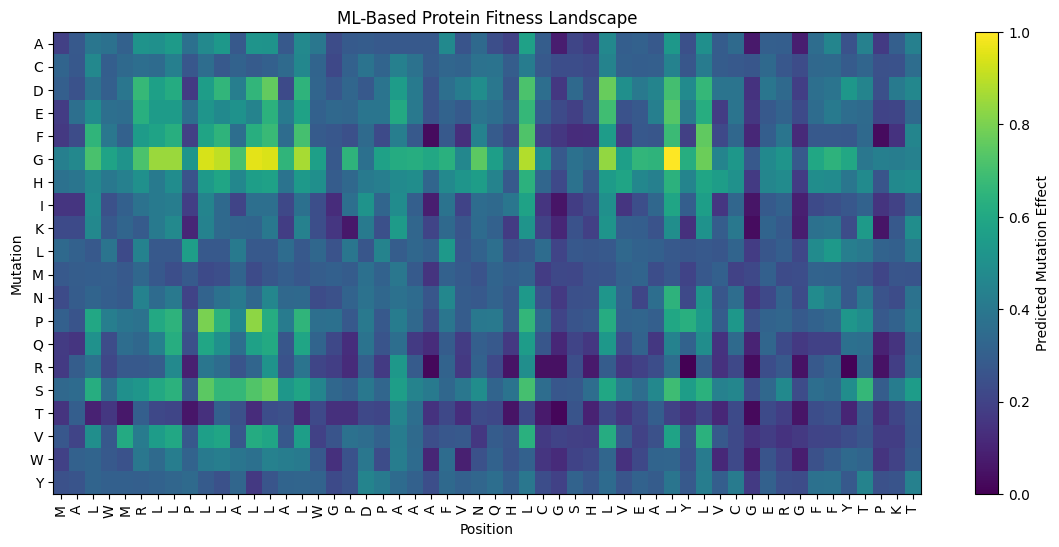

In [16]:
import matplotlib.pyplot as plt

# Normalize for visualization
heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_norm, aspect='auto', cmap='viridis')
plt.colorbar(label="Predicted Mutation Effect")
plt.yticks(range(20), amino_acids)
plt.xticks(range(L), list(sequence), rotation=90)
plt.xlabel("Position")
plt.ylabel("Mutation")
plt.title("ML-Based Protein Fitness Landscape")
plt.show()

In [17]:
position_scores = heatmap.mean(axis=0)
important_positions = np.argsort(position_scores)[-5:]
print("Most sensitive positions:", important_positions)

top_mutations = []
for i, aa in enumerate(amino_acids):
    for pos in range(L):
        top_mutations.append((heatmap[i, pos], pos, sequence[pos], aa))

top_mutations = sorted(top_mutations, reverse=True)[:10]
for score, pos, wt, mut in top_mutations:
    print(f"{wt}{pos+1}{mut} → {score:.3f}")

Most sensitive positions: [34 40 13 38 29]
L39G → 3.602
L13G → 3.396
L14G → 3.325
L10G → 3.309
L11G → 3.125
L30G → 3.028
L16G → 2.942
L7G → 2.856
L8G → 2.853
L35G → 2.797


In [18]:
!pip install py3Dmol biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.1 MB/s eta 0:00:00


In [19]:
import py3Dmol
import requests

pdb_id = "3I40"  # insulin
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

pdb_data = requests.get(url).text

In [20]:
position_scores = heatmap.mean(axis=0)

scores = (position_scores - position_scores.min()) / (
    position_scores.max() - position_scores.min()
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

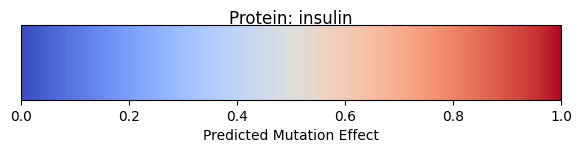

In [21]:
import matplotlib.cm as cm
import matplotlib as mpl

pdb_id = "3I40"  # insulin
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
pdb_data = requests.get(url).text

position_scores = heatmap.mean(axis=0)
scores = (position_scores - position_scores.min()) / (position_scores.max() - position_scores.min())

cmap = plt.get_cmap('coolwarm')
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, "pdb")
view.setStyle({}, {})

for i, score in enumerate(scores):
    r, g, b, _ = cmap(score)
    color = f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
    view.addSurface(py3Dmol.SAS, {"opacity":1.0, "color": color}, {"resi":i+1})

view.zoomTo()
view.show()

import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=0, vmax=1)

fig = plt.figure(figsize=(6, 1.5))

cax = fig.add_axes([0.05, 0.3, 0.9, 0.5])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label("Predicted Mutation Effect", fontsize=10)

fig.suptitle("Protein: insulin", fontsize=12, y=0.9)

plt.show()


In [22]:
print("Residues sensitive to mutation")

high_positions = np.argsort(position_scores)[-5:]

for pos in high_positions:
    print(f"Position {pos+1} ({sequence[pos]}) is highly sensitive to mutation")

Residues sensitive to mutation
Position 35 (L) is highly sensitive to mutation
Position 41 (L) is highly sensitive to mutation
Position 14 (L) is highly sensitive to mutation
Position 39 (L) is highly sensitive to mutation
Position 30 (L) is highly sensitive to mutation


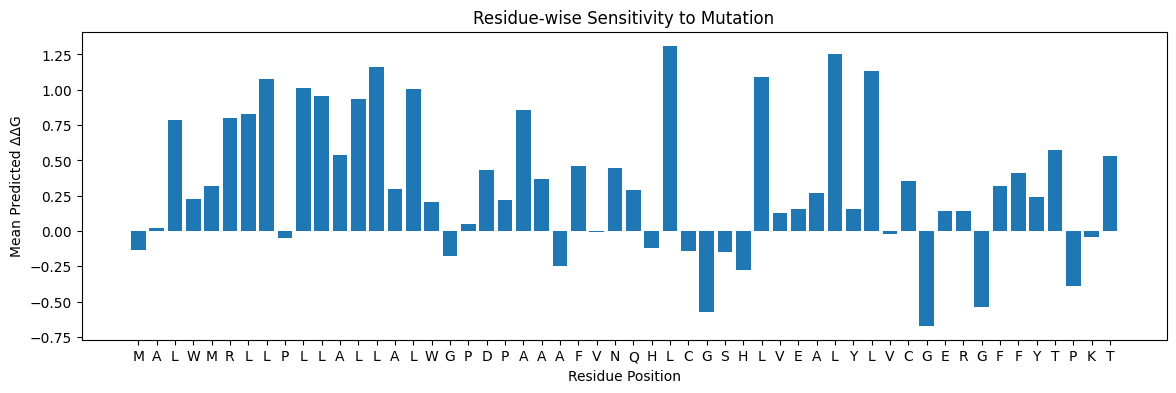

In [25]:
position_scores = heatmap.mean(axis=0)

plt.figure(figsize=(14,4))
plt.bar(range(1, len(sequence)+1), position_scores)
plt.xticks(range(1, len(sequence)+1), list(sequence))
plt.xlabel("Residue Position")
plt.ylabel("Mean Predicted ΔΔG")
plt.title("Residue-wise Sensitivity to Mutation")
plt.show()

Model Performance Metrics:
R² = 0.3612
RMSE = 1.0848 kcal/mol
MAE = 0.8144 kcal/mol
MSE = 1.1769


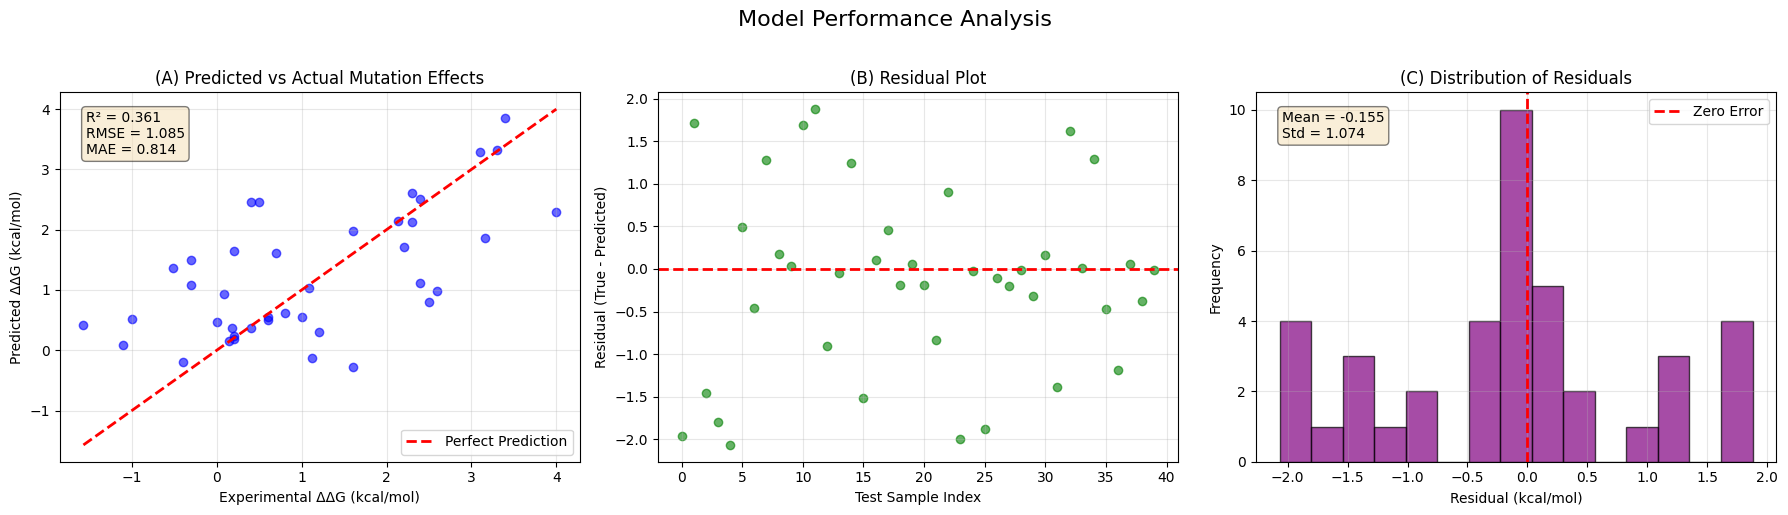

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_true = np.array(y_test)
y_pred = np.array(preds)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

residuals = y_true - y_pred

print(f"Model Performance Metrics:")
print(f"R² = {r2:.4f}")
print(f"RMSE = {rmse:.4f} kcal/mol")
print(f"MAE = {mae:.4f} kcal/mol")
print(f"MSE = {mse:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_true, y_pred, alpha=0.6, color='blue')
axes[0].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2, label='Perfect Prediction')

axes[0].set_xlabel("Experimental ΔΔG (kcal/mol)")
axes[0].set_ylabel("Predicted ΔΔG (kcal/mol)")
axes[0].set_title("(A) Predicted vs Actual Mutation Effects")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[0].text(0.05, 0.95,
             f"R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}",
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].scatter(range(len(residuals)), residuals, alpha=0.6, color='green')
axes[1].axhline(0, color='r', linestyle='--', lw=2)

axes[1].set_xlabel("Test Sample Index")
axes[1].set_ylabel("Residual (True - Predicted)")
axes[1].set_title("(B) Residual Plot")
axes[1].grid(True, alpha=0.3)

axes[2].hist(residuals, bins=15, color='purple', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[2].set_xlabel("Residual (kcal/mol)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("(C) Distribution of Residuals")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

mean_res = np.mean(residuals)
std_res = np.std(residuals)
axes[2].text(0.05, 0.95,
             f"Mean = {mean_res:.3f}\nStd = {std_res:.3f}",
             transform=axes[2].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Model Performance Analysis", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()